In [1]:
print("hello Malkeet singh")

hello Malkeet singh


In [3]:
import pandas as pd 

df = pd.read_csv("sales_data.csv")

df.head()



,Date,Product,Category,Quantity,Price,Revenue
0,2026-01-05,Laptop,Electronics,2,55000,110000
1,2026-01-08,Mouse,Accessories,10,800,8000
2,2026-01-12,Keyboard,Accessories,5,1500,7500
3,2026-01-15,Monitor,Electronics,3,12000,36000
4,2026-01-20,Laptop,Electronics,1,55000,55000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Date      12 non-null     str  
 1   Product   12 non-null     str  
 2   Category  12 non-null     str  
 3   Quantity  12 non-null     int64
 4   Price     12 non-null     int64
 5   Revenue   12 non-null     int64
dtypes: int64(3), str(3)
memory usage: 708.0 bytes


In [5]:
df.describe()

,Quantity,Price,Revenue
count,12.000000,12.000000,12.000000
mean,5.500000,17550.000000,42583.333333
std,4.033947,23020.248004,48397.423548
min,1.000000,800.000000,7500.000000
25%,2.750000,1500.000000,11625.000000
50%,4.500000,7250.000000,22000.000000
75%,7.250000,22750.000000,49750.000000
max,15.000000,55000.000000,165000.000000


In [6]:
df.isnull().sum()

Date        0
Product     0
Category    0
Quantity    0
Price       0
Revenue     0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["Date"] = pd.to_datetime(df["Date"])

In [9]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      12 non-null     datetime64[us]
 1   Product   12 non-null     str           
 2   Category  12 non-null     str           
 3   Quantity  12 non-null     int64         
 4   Price     12 non-null     int64         
 5   Revenue   12 non-null     int64         
dtypes: datetime64[us](1), int64(3), str(2)
memory usage: 708.0 bytes


In [10]:
df["Revenue"].sum()

np.int64(511000)

In [11]:
df["Quantity"].sum()

np.int64(66)

In [12]:
df["Revenue"].mean()

np.float64(42583.333333333336)

In [13]:
df.groupby("Product")["Revenue"].sum()

Product
Headphones     35000
Keyboard       18000
Laptop        330000
Monitor       108000
Mouse          20000
Name: Revenue, dtype: int64

In [15]:
df.groupby("Category")["Revenue"].sum()

Category
Accessories     73000
Electronics    438000
Name: Revenue, dtype: int64

In [16]:
df.groupby("Product")["Quantity"].sum()


Product
Headphones    14
Keyboard      12
Laptop         6
Monitor        9
Mouse         25
Name: Quantity, dtype: int64

In [17]:
df.groupby(df["Date"].dt.to_period("M"))["Revenue"].sum()

Date
2026-01    216500
2026-02     90500
2026-03    204000
Freq: M, Name: Revenue, dtype: int64

In [18]:
df.groupby(df["Date"].dt.to_period("M"))["Revenue"].sum()

Date
2026-01    216500
2026-02     90500
2026-03    204000
Freq: M, Name: Revenue, dtype: int64

In [19]:
df.groupby(df["Date"].dt.to_period("M"))["Quantity"].sum()

Date
2026-01    21
2026-02    34
2026-03    11
Freq: M, Name: Quantity, dtype: int64

In [20]:
df["Revenue"].mean()

np.float64(42583.333333333336)

In [ ]:
df.groupby("Product")["Revenue"].sum()

Product
Headphones     35000
Keyboard       18000
Laptop        330000
Monitor       108000
Mouse          20000
Name: Revenue, dtype: int64

In [21]:
product_analysis = df.groupby("Product").agg(
    Total_Quantity=("Quantity", "sum"),
    Total_Revenue=("Revenue", "sum")
)

product_analysis

,Total_Quantity,Total_Revenue
Product,,
Headphones,14,35000
Keyboard,12,18000
Laptop,6,330000
Monitor,9,108000
Mouse,25,20000


In [22]:
product_analysis["Revenue_Percentage"] = (
    product_analysis["Total_Revenue"] / product_analysis["Total_Revenue"].sum()
) * 100

product_analysis

,Total_Quantity,Total_Revenue,Revenue_Percentage
Product,,,
Headphones,14,35000,6.849315
Keyboard,12,18000,3.522505
Laptop,6,330000,64.579256
Monitor,9,108000,21.135029
Mouse,25,20000,3.913894


<Axes: title={'center': 'Revenue by Product'}, xlabel='Product', ylabel='Revenue'>

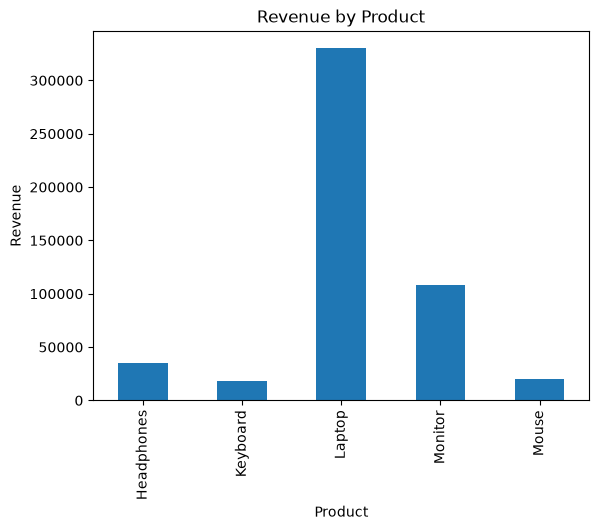

In [23]:
product_analysis["Total_Revenue"].plot(
    kind="bar",
    title="Revenue by Product",
    xlabel="Product",
    ylabel="Revenue"
)

<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='Month', ylabel='Revenue'>

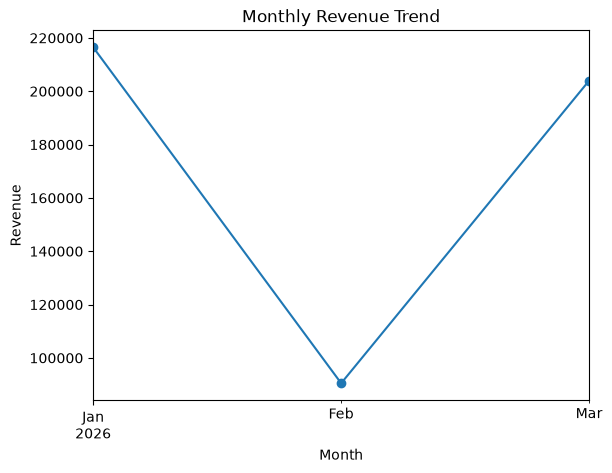

In [24]:
monthly_revenue = df.groupby(
    df["Date"].dt.to_period("M")
)["Revenue"].sum()

monthly_revenue.plot(
    kind="line",
    marker="o",
    title="Monthly Revenue Trend",
    xlabel="Month",
    ylabel="Revenue"
)

<Axes: title={'center': 'Revenue by Category'}, xlabel='Category', ylabel='Revenue'>

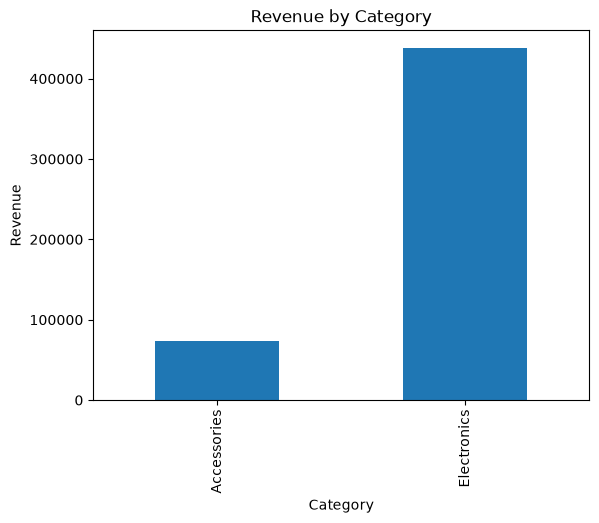

In [25]:
category_revenue = df.groupby("Category")["Revenue"].sum()

category_revenue.plot(
    kind="bar",
    title="Revenue by Category",
    xlabel="Category",
    ylabel="Revenue"
)

In [26]:
product_price = df.groupby("Product")["Price"].mean()

product_price

Product
Headphones     2500.0
Keyboard       1500.0
Laptop        55000.0
Monitor       12000.0
Mouse           800.0
Name: Price, dtype: float64

In [27]:
product_analysis["Revenue_Per_Unit"] = (
    product_analysis["Total_Revenue"] /
    product_analysis["Total_Quantity"]
)

product_analysis

,Total_Quantity,Total_Revenue,Revenue_Percentage,Revenue_Per_Unit
Product,,,,
Headphones,14,35000,6.849315,2500.0
Keyboard,12,18000,3.522505,1500.0
Laptop,6,330000,64.579256,55000.0
Monitor,9,108000,21.135029,12000.0
Mouse,25,20000,3.913894,800.0


<Axes: title={'center': 'Quantity vs Revenue by Product'}, xlabel='Total Quantity Sold', ylabel='Total Revenue'>

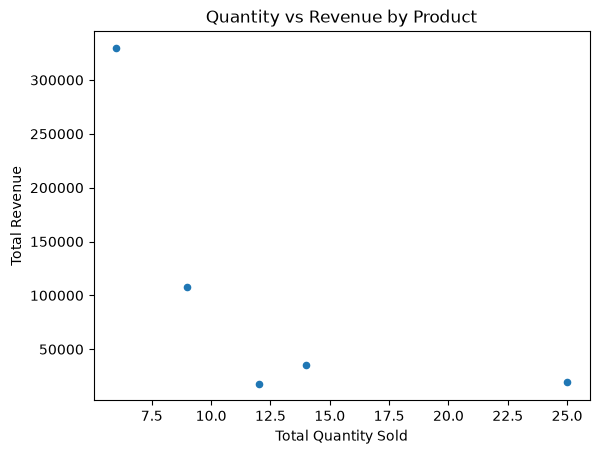

In [28]:
product_analysis.plot(
    x="Total_Quantity",
    y="Total_Revenue",
    kind="scatter",
    title="Quantity vs Revenue by Product",
    xlabel="Total Quantity Sold",
    ylabel="Total Revenue"
)

In [29]:
import sqlite3

conn = sqlite3.connect("sales.db")

df.to_sql("sales", conn, if_exists="replace", index=False)

12

In [30]:
query = """
SELECT SUM(Revenue) AS Total_Revenue
FROM sales;
"""

pd.read_sql_query(query, conn)

,Total_Revenue
0,511000


In [31]:
query = """
SELECT
    Product,
    SUM(Revenue) AS Total_Revenue
FROM sales
GROUP BY Product
ORDER BY Total_Revenue DESC;
"""

pd.read_sql_query(query, conn)

,Product,Total_Revenue
0,Laptop,330000
1,Monitor,108000
2,Headphones,35000
3,Mouse,20000
4,Keyboard,18000


In [32]:
query = """
SELECT
    Category,
    SUM(Revenue) AS Total_Revenue
FROM sales
GROUP BY Category
ORDER BY Total_Revenue DESC;
"""

pd.read_sql_query(query, conn)

,Category,Total_Revenue
0,Electronics,438000
1,Accessories,73000


In [33]:
query = """
SELECT
    substr(Date, 1, 7) AS Month,
    SUM(Revenue) AS Total_Revenue
FROM sales
GROUP BY Month
ORDER BY Month;
"""

pd.read_sql_query(query, conn)

,Month,Total_Revenue
0,2026-01,216500
1,2026-02,90500
2,2026-03,204000


In [34]:
query = """
SELECT
    Product,
    Category,
    Quantity,
    Revenue
FROM sales
WHERE Category = 'Electronics';
"""

pd.read_sql_query(query, conn)

,Product,Category,Quantity,Revenue
0,Laptop,Electronics,2,110000
1,Monitor,Electronics,3,36000
2,Laptop,Electronics,1,55000
3,Monitor,Electronics,4,48000
4,Laptop,Electronics,3,165000
5,Monitor,Electronics,2,24000


In [35]:
query = """
SELECT
    Product,
    Quantity,
    Price,
    Revenue
FROM sales
WHERE Revenue > 50000
ORDER BY Revenue DESC;
"""

pd.read_sql_query(query, conn)

,Product,Quantity,Price,Revenue
0,Laptop,3,55000,165000
1,Laptop,2,55000,110000
2,Laptop,1,55000,55000


In [ ]:
query = """
SELECT
    Product,
    SUM(Revenue) AS Total_Revenue
FROM sales
GROUP BY Product
HAVING SUM(Revenue) > 50000
ORDER BY Total_Revenue DESC;
"""

pd.read_sql_query(query, conn)

,Product,Total_Revenue
0,Laptop,330000
1,Monitor,108000


In [38]:
query = """
SELECT
    Product,
    Revenue,
    CASE
        WHEN Revenue > 50000 THEN 'High'
        WHEN Revenue >= 20000 THEN 'Medium'
        ELSE 'Low'
    END AS Revenue_Category
FROM sales
ORDER BY Revenue DESC;
"""

pd.read_sql_query(query, conn)

,Product,Revenue,Revenue_Category
0,Laptop,165000,High
1,Laptop,110000,High
2,Laptop,55000,High
3,Monitor,48000,Medium
4,Monitor,36000,Medium
5,Monitor,24000,Medium
6,Headphones,20000,Medium
7,Headphones,15000,Low
8,Mouse,12000,Low
9,Keyboard,10500,Low


In [39]:
query = """
WITH product_revenue AS (
    SELECT
        Product,
        SUM(Revenue) AS Total_Revenue
    FROM sales
    GROUP BY Product
)

SELECT
    Product,
    Total_Revenue
FROM product_revenue
WHERE Total_Revenue > 50000
ORDER BY Total_Revenue DESC;
"""

pd.read_sql_query(query, conn)

,Product,Total_Revenue
0,Laptop,330000
1,Monitor,108000


In [40]:
query = """
SELECT COUNT(*) AS Total_Transactions
FROM sales;
"""

pd.read_sql_query(query, conn)

,Total_Transactions
0,12


In [41]:
query = """
SELECT
    Product,
    COUNT(*) AS Transaction_Count
FROM sales
GROUP BY Product
ORDER BY Transaction_Count DESC;
"""

pd.read_sql_query(query, conn)

,Product,Transaction_Count
0,Monitor,3
1,Laptop,3
2,Mouse,2
3,Keyboard,2
4,Headphones,2


In [42]:
query = """
SELECT
    Product,
    AVG(Price) AS Average_Price
FROM sales
GROUP BY Product
ORDER BY Average_Price DESC;
"""

pd.read_sql_query(query, conn)

,Product,Average_Price
0,Laptop,55000.0
1,Monitor,12000.0
2,Headphones,2500.0
3,Keyboard,1500.0
4,Mouse,800.0


In [43]:
query = """
SELECT
    Product,
    MIN(Price) AS Minimum_Price,
    MAX(Price) AS Maximum_Price
FROM sales
GROUP BY Product
ORDER BY Maximum_Price DESC;
"""

pd.read_sql_query(query, conn)

,Product,Minimum_Price,Maximum_Price
0,Laptop,55000,55000
1,Monitor,12000,12000
2,Headphones,2500,2500
3,Keyboard,1500,1500
4,Mouse,800,800


In [45]:
query = """
SELECT
    Product,
    MIN(Price) AS Minimum_Price,
    MAX(Price) AS Maximum_Price
FROM sales
GROUP BY Product
ORDER BY Maximum_Price DESC;
"""

pd.read_sql_query(query, conn)

,Product,Minimum_Price,Maximum_Price
0,Laptop,55000,55000
1,Monitor,12000,12000
2,Headphones,2500,2500
3,Keyboard,1500,1500
4,Mouse,800,800


In [46]:
query = """
SELECT
    Category,
    SUM(Quantity) AS Total_Quantity,
    SUM(Revenue) AS Total_Revenue,
    AVG(Price) AS Average_Price
FROM sales
GROUP BY Category
ORDER BY Total_Revenue DESC;
"""

pd.read_sql_query(query, conn)

,Category,Total_Quantity,Total_Revenue,Average_Price
0,Electronics,15,438000,33500.0
1,Accessories,51,73000,1600.0


In [47]:
query = """
SELECT DISTINCT Product
FROM sales;
"""

pd.read_sql_query(query, conn)

,Product
0,Laptop
1,Mouse
2,Keyboard
3,Monitor
4,Headphones


In [48]:
query = """
SELECT DISTINCT Category
FROM sales;
"""

pd.read_sql_query(query, conn)

,Category
0,Electronics
1,Accessories


In [49]:
query = """
SELECT
    Product,
    SUM(Revenue) AS Total_Revenue
FROM sales
GROUP BY Product
ORDER BY Total_Revenue DESC
LIMIT 3;
"""

pd.read_sql_query(query, conn)

,Product,Total_Revenue
0,Laptop,330000
1,Monitor,108000
2,Headphones,35000


In [50]:
query = """
SELECT
    Product,
    SUM(Quantity) AS Total_Quantity
FROM sales
GROUP BY Product
ORDER BY Total_Quantity DESC
LIMIT 3;
"""

pd.read_sql_query(query, conn)

,Product,Total_Quantity
0,Mouse,25
1,Headphones,14
2,Keyboard,12


In [51]:
query = """
SELECT
    Product,
    SUM(Revenue) AS Total_Revenue
FROM sales
GROUP BY Product
HAVING SUM(Revenue) > (
    SELECT AVG(Product_Revenue)
    FROM (
        SELECT
            Product,
            SUM(Revenue) AS Product_Revenue
        FROM sales
        GROUP BY Product
    )
)
ORDER BY Total_Revenue DESC;
"""

pd.read_sql_query(query, conn)

,Product,Total_Revenue
0,Laptop,330000
1,Monitor,108000


In [52]:
query = """
CREATE TABLE IF NOT EXISTS products (
    Product TEXT PRIMARY KEY,
    Brand TEXT,
    Supplier TEXT
);

INSERT OR REPLACE INTO products (Product, Brand, Supplier)
VALUES
    ('Laptop', 'Dell', 'Tech Supplier A'),
    ('Mouse', 'Logitech', 'Accessory Supplier B'),
    ('Keyboard', 'HP', 'Accessory Supplier B'),
    ('Monitor', 'Samsung', 'Tech Supplier A'),
    ('Headphones', 'Sony', 'Audio Supplier C');
"""

conn.executescript(query)
conn.commit()

In [53]:
pd.read_sql_query("SELECT * FROM products;", conn)

,Product,Brand,Supplier
0,Laptop,Dell,Tech Supplier A
1,Mouse,Logitech,Accessory Supplier B
2,Keyboard,HP,Accessory Supplier B
3,Monitor,Samsung,Tech Supplier A
4,Headphones,Sony,Audio Supplier C


In [54]:
query = """
SELECT
    s.Product,
    s.Quantity,
    s.Revenue,
    p.Brand,
    p.Supplier
FROM sales AS s
INNER JOIN products AS p
    ON s.Product = p.Product;
"""

pd.read_sql_query(query, conn)

,Product,Quantity,Revenue,Brand,Supplier
0,Laptop,2,110000,Dell,Tech Supplier A
1,Mouse,10,8000,Logitech,Accessory Supplier B
2,Keyboard,5,7500,HP,Accessory Supplier B
3,Monitor,3,36000,Samsung,Tech Supplier A
4,Laptop,1,55000,Dell,Tech Supplier A
5,Headphones,8,20000,Sony,Audio Supplier C
6,Mouse,15,12000,Logitech,Accessory Supplier B
7,Monitor,4,48000,Samsung,Tech Supplier A
8,Keyboard,7,10500,HP,Accessory Supplier B
9,Laptop,3,165000,Dell,Tech Supplier A


In [55]:
query = """
SELECT
    s.Product,
    s.Revenue,
    p.Brand,
    p.Supplier
FROM sales AS s
LEFT JOIN products AS p
    ON s.Product = p.Product;
"""

pd.read_sql_query(query, conn)

,Product,Revenue,Brand,Supplier
0,Laptop,110000,Dell,Tech Supplier A
1,Mouse,8000,Logitech,Accessory Supplier B
2,Keyboard,7500,HP,Accessory Supplier B
3,Monitor,36000,Samsung,Tech Supplier A
4,Laptop,55000,Dell,Tech Supplier A
5,Headphones,20000,Sony,Audio Supplier C
6,Mouse,12000,Logitech,Accessory Supplier B
7,Monitor,48000,Samsung,Tech Supplier A
8,Keyboard,10500,HP,Accessory Supplier B
9,Laptop,165000,Dell,Tech Supplier A


In [56]:
query = """
SELECT
    p.Brand,
    SUM(s.Revenue) AS Total_Revenue
FROM sales AS s
INNER JOIN products AS p
    ON s.Product = p.Product
GROUP BY p.Brand
ORDER BY Total_Revenue DESC;
"""

pd.read_sql_query(query, conn)

,Brand,Total_Revenue
0,Dell,330000
1,Samsung,108000
2,Sony,35000
3,Logitech,20000
4,HP,18000


In [57]:
query = """
SELECT
    p.Brand,
    SUM(s.Revenue) AS Total_Revenue
FROM sales AS s
INNER JOIN products AS p
    ON s.Product = p.Product
WHERE s.Category = 'Electronics'
GROUP BY p.Brand
ORDER BY Total_Revenue DESC;
"""

pd.read_sql_query(query, conn)

,Brand,Total_Revenue
0,Dell,330000
1,Samsung,108000


In [58]:
query = """
SELECT
    p.Brand,
    SUM(s.Revenue) AS Total_Revenue
FROM sales AS s
INNER JOIN products AS p
    ON s.Product = p.Product
GROUP BY p.Brand
HAVING SUM(s.Revenue) > 50000
ORDER BY Total_Revenue DESC;
"""

pd.read_sql_query(query, conn)

,Brand,Total_Revenue
0,Dell,330000
1,Samsung,108000


In [59]:
query = """
SELECT
    Product,
    SUM(Revenue) AS Total_Revenue,
    RANK() OVER (ORDER BY SUM(Revenue) DESC) AS Revenue_Rank
FROM sales
GROUP BY Product
ORDER BY Revenue_Rank;
"""

pd.read_sql_query(query, conn)

,Product,Total_Revenue,Revenue_Rank
0,Laptop,330000,1
1,Monitor,108000,2
2,Headphones,35000,3
3,Mouse,20000,4
4,Keyboard,18000,5


In [60]:
query = """
WITH product_revenue AS (
    SELECT
        Product,
        SUM(Revenue) AS Total_Revenue
    FROM sales
    GROUP BY Product
)

SELECT
    Product,
    Total_Revenue,
    RANK() OVER (ORDER BY Total_Revenue DESC) AS Rank_Number,
    DENSE_RANK() OVER (ORDER BY Total_Revenue DESC) AS Dense_Rank,
    ROW_NUMBER() OVER (ORDER BY Total_Revenue DESC) AS Row_Number
FROM product_revenue
ORDER BY Total_Revenue DESC;
"""

pd.read_sql_query(query, conn)

,Product,Total_Revenue,Rank_Number,Dense_Rank,Row_Number
0,Laptop,330000,1,1,1
1,Monitor,108000,2,2,2
2,Headphones,35000,3,3,3
3,Mouse,20000,4,4,4
4,Keyboard,18000,5,5,5


In [61]:
query = """
WITH product_rank AS (
    SELECT
        Product,
        SUM(Revenue) AS Total_Revenue,
        RANK() OVER (ORDER BY SUM(Revenue) DESC) AS Revenue_Rank
    FROM sales
    GROUP BY Product
)

SELECT
    Product,
    Total_Revenue,
    Revenue_Rank
FROM product_rank
WHERE Revenue_Rank <= 3
ORDER BY Revenue_Rank;
"""

pd.read_sql_query(query, conn)

,Product,Total_Revenue,Revenue_Rank
0,Laptop,330000,1
1,Monitor,108000,2
2,Headphones,35000,3
